# PRCP-1021-InsCostPred

### TABLE OF CONTENTS
1. Understanding the Objective
2. Importing Required Libraries
3. Loading the Dataset and EDA
4. Scaling & Feature Engineering
5. Model Development
6. Conclusion and Insights

### 1. Objective:
     Building a model to predict the insurance price changed to the customer.

### 2. Importing Necessaary Libraries

In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#Importing the Data Set

ins = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Insurance Cost\Data\datasets_13720_18513_insurance(1).csv")
ins

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### 3.Exploratory Data Analysis:
Duplicate Check: Verify the dataset for any duplicate entries to prevent redundant data. If duplicates are found, they should be removed to enhance the model’s performance.

Null Value Check: Inspect the dataset for missing values to avoid bias. If null values are present, they should be appropriately imputed or replaced based on the nature of the data.

Data Type Verification: Examine the data types of all features. If any non-numerical features exist, they must be encoded into numerical format before model training.

Statistical Summary: Perform an overall statistical analysis to understand metrics such as mean, median, standard deviation, and maximum values. This helps in effective feature engineering.

Visualization: Create visualizations to analyze features and gain better insights into their relationships.

In [22]:
ins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
ins.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [24]:
ins.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [25]:
ins.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [30]:
ins.duplicated().sum()

np.int64(0)

In [27]:
ins.drop_duplicates(inplace=True)

In [38]:
ins = ins.drop('children', axis=1)

In [39]:
ins

,age,sex,bmi,smoker,region,charges
0,19,female,27.900,yes,southwest,16884.92400
1,18,male,33.770,no,southeast,1725.55230
2,28,male,33.000,no,southeast,4449.46200
3,33,male,22.705,no,northwest,21984.47061
4,32,male,28.880,no,northwest,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,no,northwest,10600.54830
1334,18,female,31.920,no,northeast,2205.98080
1335,18,female,36.850,no,southeast,1629.83350
1336,21,female,25.800,no,southwest,2007.94500


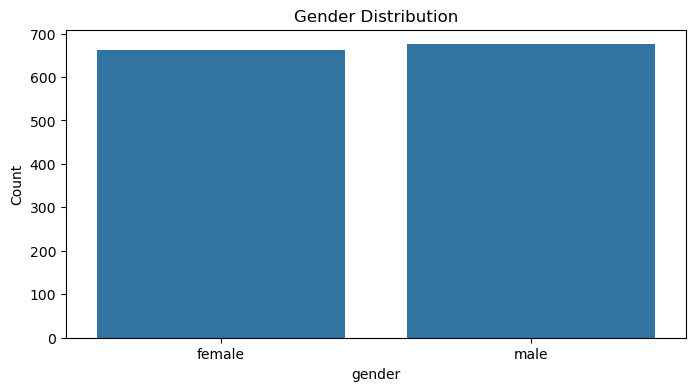

sex
male      0.504862
female    0.495138
Name: proportion, dtype: float64


In [140]:
plt.figure(figsize=(8,4)) 
sns.countplot(x='sex', data=ins) 
plt.title("Gender Distribution") 
plt.xlabel("gender") 
plt.ylabel("Count") 
plt.show() 
print(ins['sex'].value_counts(normalize=True))

- The dataset shows an almost equal split between males and females, indicating no significant class imbalance in the gender feature.

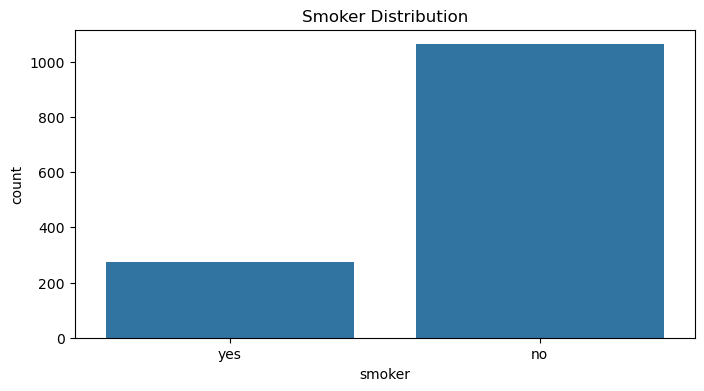

smoker
no     0.795064
yes    0.204936
Name: proportion, dtype: float64


In [43]:
plt.figure(figsize=(8,4))
sns.countplot(x='smoker', data=ins)
plt.title("Smoker Distribution")
plt.xlabel("smoker")
plt.ylabel("count")
plt.show()
print(ins['smoker'].value_counts(normalize=True))

- The smoker variable is imbalanced, with a much larger proportion of non-smokers (79.5%) compared to smokers (20.5%). This imbalance should be considered because smoking has a major impact on insurance costs.

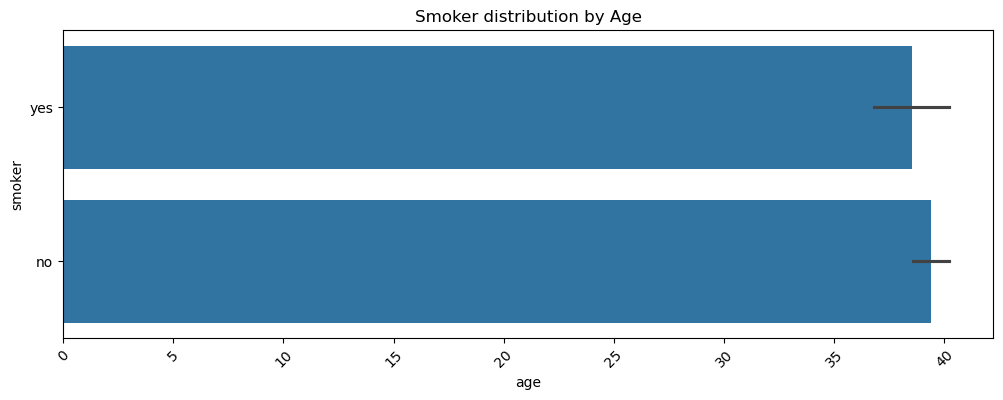

In [49]:
plt.figure(figsize=(12,4))
sns.barplot(x='age', y='smoker', data=ins)
plt.title("Smoker distribution by Age")
plt.xticks(rotation=45)
plt.show()

- The average age for smokers and non-smokers is nearly the same, indicating that smoking habits do not vary significantly by age in this dataset.

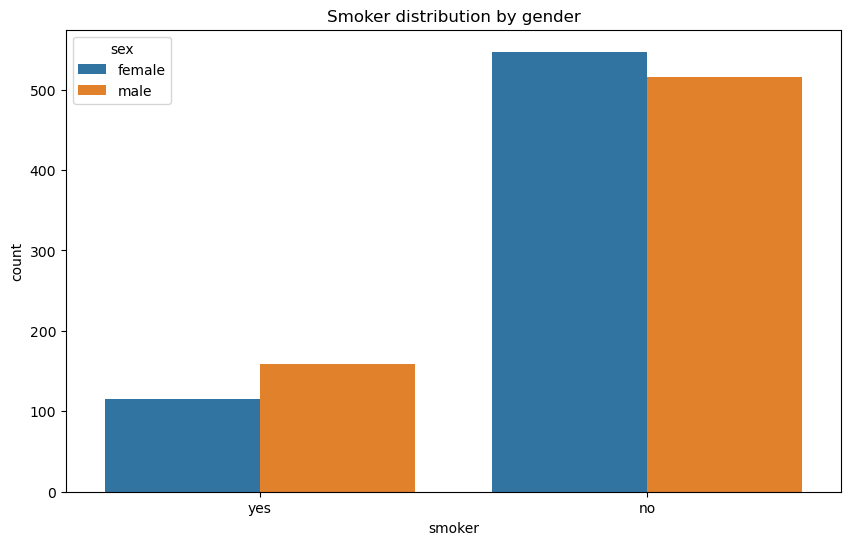

In [147]:
plt.figure(figsize=(10,6))
sns.countplot(x='smoker', hue='sex', data=ins)
plt.title("Smoker distribution by gender")
plt.xticks()
plt.show()

- The plot indicates that both males and females have a higher proportion of non-smokers; however, the number of male smokers is slightly higher than female smokers. This suggests that smoking behavior is somewhat more prevalent among males in this dataset.

In [65]:
num_cols = ins.drop("charges", axis=1)
num_cols

,age,sex,bmi,smoker,region
0,19,female,27.900,yes,southwest
1,18,male,33.770,no,southeast
2,28,male,33.000,no,southeast
3,33,male,22.705,no,northwest
4,32,male,28.880,no,northwest
...,...,...,...,...,...
1333,50,male,30.970,no,northwest
1334,18,female,31.920,no,northeast
1335,18,female,36.850,no,southeast
1336,21,female,25.800,no,southwest


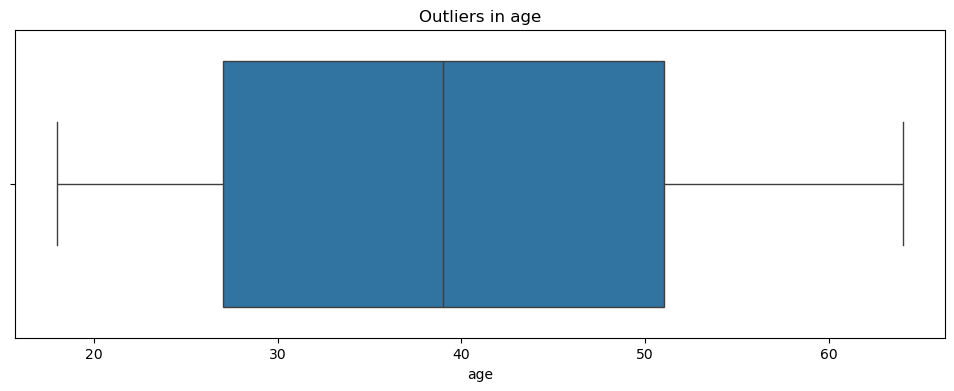

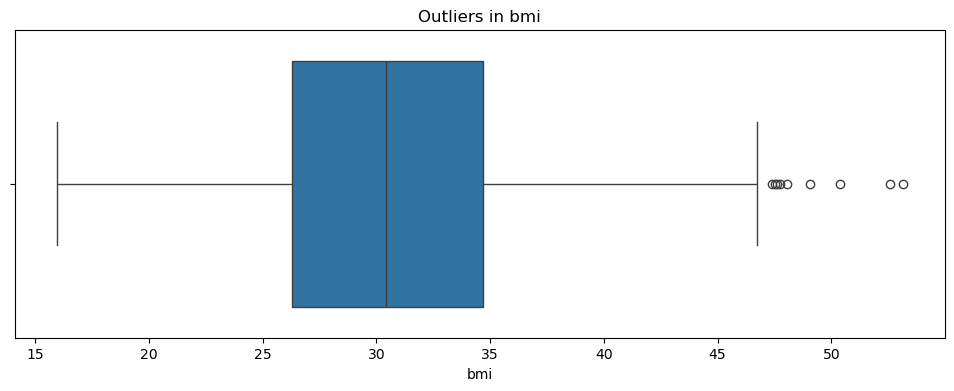

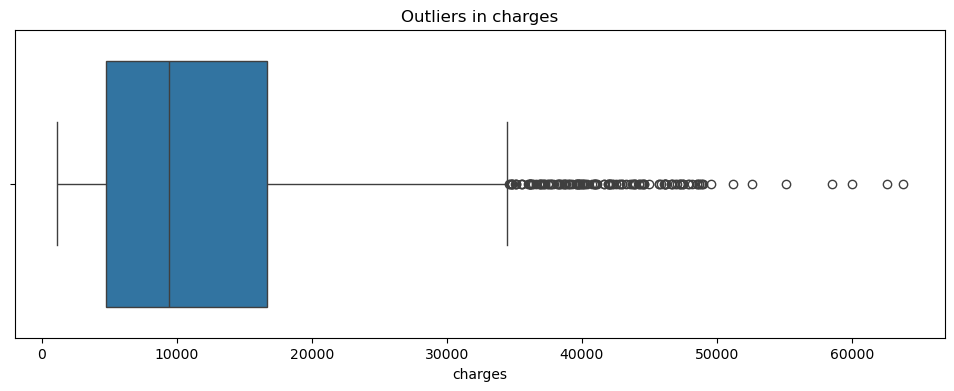

In [70]:
num_cols = ins.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=ins[col])
    plt.title(f"Outliers in {col}")
    plt.show()

#### Outlier analysis shows that:

- Age has no significant extreme values and appears uniformly distributed.

- BMI contains a few high-end outliers, indicating individuals with unusually high body mass.

- Charges exhibits many high-value outliers, representing patients who incurred exceptionally large medical expenses.

- These outliers are meaningful and expected in the context of health insurance data. Removing them would incorrectly distort the natural distribution   of high-risk individuals. Therefore, all outliers are retained to preserve the integrity of the dataset and improve model performance in predicting    real-life medical cost variations.

In [72]:
pip install category_encoders

In [73]:
from category_encoders import BinaryEncoder

encoder = BinaryEncoder(cols=['sex','smoker','region'])
ins_encoded = encoder.fit_transform(ins)

In [74]:
ins_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex_0     1337 non-null   int64  
 2   sex_1     1337 non-null   int64  
 3   bmi       1337 non-null   float64
 4   smoker_0  1337 non-null   int64  
 5   smoker_1  1337 non-null   int64  
 6   region_0  1337 non-null   int64  
 7   region_1  1337 non-null   int64  
 8   region_2  1337 non-null   int64  
 9   charges   1337 non-null   float64
dtypes: float64(2), int64(8)
memory usage: 114.9 KB


In [75]:
ins_encoded.head()

,age,sex_0,sex_1,bmi,smoker_0,smoker_1,region_0,region_1,region_2,charges
0,19,0,1,27.900,0,1,0,0,1,16884.92400
1,18,1,0,33.770,1,0,0,1,0,1725.55230
2,28,1,0,33.000,1,0,0,1,0,4449.46200
3,33,1,0,22.705,1,0,0,1,1,21984.47061
4,32,1,0,28.880,1,0,0,1,1,3866.85520


In [76]:
x=ins_encoded.drop('charges',axis=1)

In [77]:
y=ins_encoded['charges']

#### 4. Scaling and Feature Engineering

In [78]:
scaler = StandardScaler()
x=scaler.fit_transform(x)

In [86]:
x

array([[-1.44041773, -1.00977099,  1.00977099, ..., -0.5655458 ,
        -1.02960791,  1.02960791],
       [-1.51164747,  0.99032355, -0.99032355, ..., -0.5655458 ,
         0.97124351, -0.97124351],
       [-0.79935006,  0.99032355, -0.99032355, ..., -0.5655458 ,
         0.97124351, -0.97124351],
       ...,
       [-1.51164747, -1.00977099,  1.00977099, ..., -0.5655458 ,
         0.97124351, -0.97124351],
       [-1.29795825, -1.00977099,  1.00977099, ..., -0.5655458 ,
        -1.02960791,  1.02960791],
       [ 1.55123139, -1.00977099,  1.00977099, ..., -0.5655458 ,
         0.97124351,  1.02960791]])

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train", y_train.shape)
print("y_test",y_test.shape)

x_train (935, 9)
x_test (402, 9)
y_train (935,)
y_test (402,)


### 5. Model Development
Testing with Multiple Models for Better Prediction

In [161]:
lr=LinearRegression()
lr

LinearRegression()

In [162]:
lr.fit(x_train,y_train)

LinearRegression()

In [163]:
y_pred_lr = lr.predict(x_test)

In [164]:
y_predc_lr = lr.predict(x_train)

#### Random Forest

#### Using GridSearchCV to understand better parameters

In [166]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='r2'
)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_rf = best_model.predict(x_test)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


In [167]:
final_rf = RandomForestRegressor(**grid_search.best_params_, random_state=42)

final_rf.fit(x_train, y_train)
 

RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42)

In [168]:
y_pred_rf = final_rf.predict(x_test)

In [169]:
y_predc_rf = final_rf.predict(x_train)

#### LightGBM Regressor (RandomizedSearchCV)

In [96]:
from lightgbm import LGBMRegressor

from sklearn.model_selection import RandomizedSearchCV

import numpy as np
 
 
lgbm = LGBMRegressor(random_state=42)
 
 
param_dist = {

    'num_leaves': [31, 50, 70, 100],

    'max_depth': [-1, 10, 15, 20],

    'learning_rate': [0.01, 0.03, 0.05, 0.1],

    'n_estimators': [300, 500, 700, 1000],

    'subsample': [0.7, 0.8, 0.9, 1.0],

    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]

}
 
 
random_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=param_dist,

    n_iter=20,                  

    scoring='r2',

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=2

)
 
 
random_search.fit(x_train, y_train)
 
print("Best parameters:", random_search.best_params_)

best_lgbm = random_search.best_estimator_
 

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 324
[LightGBM] [Info] Number of data points in the train set: 935, number of used features: 9
[LightGBM] [Info] Start training from score 13035.065786
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [170]:
final_lgbm = LGBMRegressor(**random_search.best_params_, random_state=42)
final_lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 324
[LightGBM] [Info] Number of data points in the train set: 935, number of used features: 9
[LightGBM] [Info] Start training from score 13035.065786
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMRegressor(colsample_bytree=0.9, learning_rate=0.01, max_depth=10,
              n_estimators=500, num_leaves=50, random_state=42)

In [171]:
y_pred_lgbm = final_lgbm.predict(x_test)

C:\Users\User\anaconda3a\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [172]:
y_predc_lgbm = final_lgbm.predict(x_train)
 

C:\Users\User\anaconda3a\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### XGBoost Regressor

In [237]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05],
    'max_depth': [3, 4, 5],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0.1, 0.2],
    'reg_lambda': [1, 1.5]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

best_xgb = grid_search.best_estimator_

y_pred_xgb = best_xgb.predict(x_test)



Fitting 3 folds for each of 576 candidates, totalling 1728 fits


In [238]:
y_predc_xgb = best_xgb.predict(x_train)

### Consolidated Evaluation Report

In [239]:
def evaluate_model(name, y_train, y_train_pred, y_test, y_test_pred):
    return {
        "Model": name,
        
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),

        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),

        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }


In [240]:
results_list = []

# Linear Regression
results_list.append(
    evaluate_model(
        "Linear Regression",
        y_train, y_predc_lr,
        y_test, y_pred_lr
    )
)
# Randomforest
results_list.append(
    evaluate_model(
        "Randomforest",
        y_train, y_predc_rf,
        y_test, y_pred_rf
    )
)
# XGBoost
results_list.append(
    evaluate_model(
        "XGBoost",
        y_train, y_predc_xgb,
        y_test, y_pred_xgb
    )
)

# LightGBM
results_list.append(
    evaluate_model(
        "LightGBM",
        y_train, y_predc_lgbm,
        y_test, y_pred_lgbm
    )
)


results_df = pd.DataFrame(results_list)
results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.733403,0.771645,4196.800276,4207.864382,6016.755257,6251.048905
1,Randomforest,0.900466,0.867694,2027.200208,2624.944760,3676.389723,4758.137827
2,XGBoost,0.874534,0.871808,2335.333479,2589.870374,4127.604647,4683.577732
3,LightGBM,0.904653,0.866585,2046.942162,2629.101735,3598.219438,4778.041163


### 7. Conlusion

- Linear Regression performed poorly due to its inability to capture the non-linear relationships present in the data. XGBoost achieved extremely high accuracy on the training set but showed a significant drop on the test set. This indicates severe overfitting, meaning the model learned the noise instead of the underlying patterns. 

- LightGBM produced stable and efficient results and performed significantly better than Linear Regression. However, its test-set errors were marginally higher than those of the Random Forest model, preventing it from achieving the best overall performance despite its scalability and computational efficiency.

- Among all the models tested, Random Forest delivered the most reliable and consistent performance. It achieved the highest Test R² score and the       lowest MAE and RMSE compared to the other techniques. The small gap between training and test performance indicates strong generalization, making      Random Forest the most dependable model for this dataset. Since this is a regression problem with continuous target values, metrics such as MAE and    RMSE give a more meaningful understanding of error magnitude than training accuracy alone. 

- Based on these evaluation metrics and the model’s stability, Random Forest is considered the most suitable for this dataset.